<a href="https://colab.research.google.com/github/Adriandzidan/Tugas-Kecerdasan-Buatan/blob/main/JOBSHEET08_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
%matplotlib inline

## 1. Gathering Data

Membaca dataset `iklan_sosmed.csv` yang berisi data calon pembeli yang menjadi target iklan media sosial.

In [ ]:
df = pd.read_csv("data/iklan_sosmed.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15000000,Male,60,16632,1
1,15000001,Female,51,55760,1
2,15000002,Female,31,84600,0
3,15000003,Male,59,138990,1
4,15000004,Male,39,114661,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.0000
mean,1.500020e+07,39.742500,87644.280000,0.5625
std,1.156143e+02,12.540708,60547.860909,0.4967
min,1.500000e+07,18.000000,15591.000000,0.0000
25%,1.500010e+07,28.000000,49146.000000,0.0000
50%,1.500020e+07,40.000000,84410.000000,1.0000
75%,1.500030e+07,51.000000,116742.000000,1.0000
max,1.500040e+07,60.000000,520000.000000,1.0000


## 2. Data Preparation dengan One Hot Encoding

Kolom `Gender` bersifat kategorikal (`Male`/`Female`) sehingga perlu diubah menjadi representasi numerik menggunakan One Hot Encoding agar dapat diproses oleh algoritma machine learning.

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(df[['Gender']])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Gender']))

df_encoded = pd.concat([df.reset_index(drop=True), encoded_df], axis=1)
print(df_encoded.head())

    User ID  Gender  Age  EstimatedSalary  Purchased  Gender_Female  \
0  15000000    Male   60            16632          1            0.0   
1  15000001  Female   51            55760          1            1.0   
2  15000002  Female   31            84600          0            1.0   
3  15000003    Male   59           138990          1            0.0   
4  15000004    Male   39           114661          1            0.0   

   Gender_Male  
0          1.0  
1          0.0  
2          0.0  
3          1.0  
4          1.0  


**Insight:** Kolom `Gender` berhasil diubah menjadi dua kolom biner baru, `Gender_Female` dan `Gender_Male`, yang masing-masing bernilai 1 jika sesuai kategori dan 0 jika tidak. Representasi ini memungkinkan model machine learning membaca informasi gender tanpa asumsi urutan/tingkatan (berbeda dengan label encoding).

## 3. Data Preparation dengan Outlier Removal

Beberapa nilai `EstimatedSalary` pada dataset ini sangat ekstrem dibanding sebagian besar data (outlier), sehingga perlu dihapus agar tidak mengganggu analisis dan pemodelan. Outlier dideteksi menggunakan **z-score**: data dengan `|z-score| > 3` dianggap outlier.

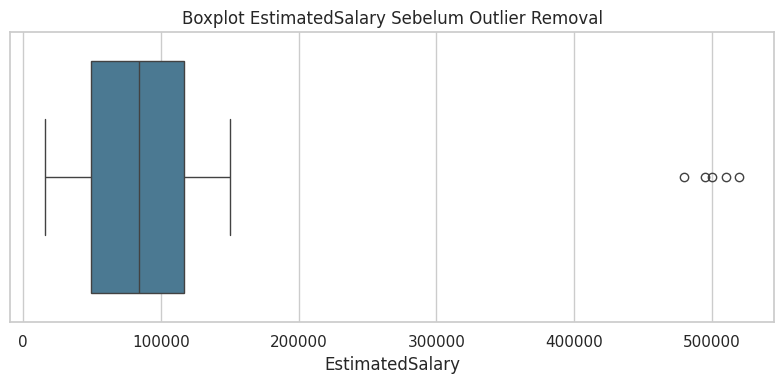

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_encoded['EstimatedSalary'], color='#3f7d9e')
plt.title('Boxplot EstimatedSalary Sebelum Outlier Removal')
plt.tight_layout()
plt.show()

In [ ]:
z_scores = (df_encoded['EstimatedSalary'] - df_encoded['EstimatedSalary'].mean()) / df_encoded['EstimatedSalary'].std()

print("Jumlah outlier terdeteksi:", (z_scores.abs() > 3).sum())

df_no_outlier = df_encoded[z_scores.abs() <= 3].reset_index(drop=True)
print("Jumlah baris sebelum:", len(df_encoded), "| sesudah:", len(df_no_outlier))

Jumlah outlier terdeteksi: 5
Jumlah baris sebelum: 400 | sesudah: 395


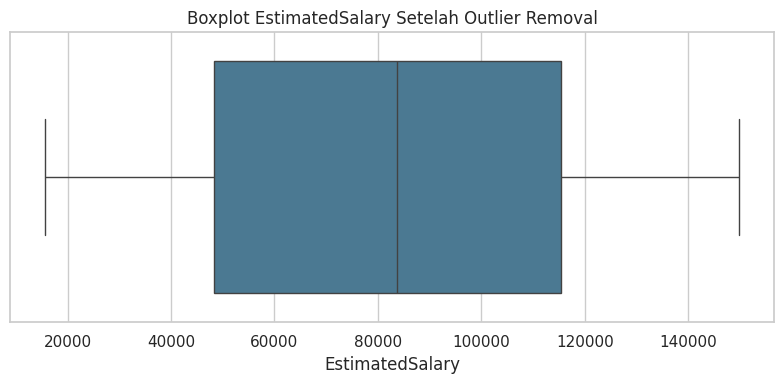

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_no_outlier['EstimatedSalary'], color='#3f7d9e')
plt.title('Boxplot EstimatedSalary Setelah Outlier Removal')
plt.tight_layout()
plt.show()

## 4. Data Preparation dengan Normalization

Normalisasi menggunakan **MinMaxScaler** mengubah skala kolom `Age` dan `EstimatedSalary` ke rentang 0-1 agar kedua fitur memiliki kontribusi yang setara saat pemodelan, tanpa didominasi oleh fitur dengan skala nilai lebih besar.

In [ ]:
df_norm = df_no_outlier.copy()

minmax_scaler = MinMaxScaler()
df_norm[['Age', 'EstimatedSalary']] = minmax_scaler.fit_transform(df_norm[['Age', 'EstimatedSalary']])

df_norm[['Age', 'EstimatedSalary']].describe()

,Age,EstimatedSalary
count,395.000000,395.000000
mean,0.516576,0.497590
std,0.298245,0.289795
min,0.000000,0.000000
25%,0.238095,0.244193
50%,0.523810,0.506646
75%,0.785714,0.742715
max,1.000000,1.000000


In [ ]:
df_std = df_no_outlier.copy()

std_scaler = StandardScaler()
df_std[['Age', 'EstimatedSalary']] = std_scaler.fit_transform(df_std[['Age', 'EstimatedSalary']])

df_std[['Age', 'EstimatedSalary']].describe()

,Age,EstimatedSalary
count,3.950000e+02,3.950000e+02
mean,1.304161e-16,-3.597685e-17
std,1.001268e+00,1.001268e+00
min,-1.734253e+00,-1.719223e+00
25%,-9.349180e-01,-8.755108e-01
50%,2.428358e-02,3.128805e-02
75%,9.035517e-01,8.469298e-01
max,1.622953e+00,1.735873e+00


## 6. Pembagian Dataset menjadi Data Training dan Data Testing

Dataset yang telah melalui proses data preparation (one-hot encoding, outlier removal, standardization) dibagi menjadi **80% data latih** dan **20% data uji** menggunakan `train_test_split`, dengan `Purchased` sebagai target/label.

In [ ]:
feature_cols = ['Age', 'EstimatedSalary', 'Gender_Female', 'Gender_Male']
X = df_std[feature_cols]
y = df_std['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Jumlah data latih: 316
Jumlah data uji  : 79


## 7. Cross Validation

Sebagai tambahan evaluasi, dilakukan **5-fold cross validation** menggunakan `DecisionTreeClassifier` pada seluruh data fitur (`X`) dan target (`y`) untuk memperoleh estimasi performa model yang lebih stabil dibanding satu kali split data.

In [ ]:
clf = DecisionTreeClassifier(random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=5)

print("Akurasi tiap fold:", cv_scores)
print("Rata-rata akurasi:", cv_scores.mean().round(4))
print("Standar deviasi  :", cv_scores.std().round(4))

Akurasi tiap fold: [0.78481013 0.79746835 0.78481013 0.81012658 0.72151899]
Rata-rata akurasi: 0.7797
Standar deviasi  : 0.0306
